In [65]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import time
import gc
import pickle
from datetime import datetime
import cmaps

import matplotlib.ticker as ticker


from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from wave_tools.filters import CCKWFilter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
# 配置参数
CACHE_DIR = "./cache/kelvin_wave/"
REGRESSION_CACHE_DIR = os.path.join(CACHE_DIR, "latent_heat_flux_with_lon")
FIG_SAVE_DIR = "./figures/latent_heat_flux_composite/"

# 创建必要的目录
for d in [CACHE_DIR, REGRESSION_CACHE_DIR, FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)

# 分析参数
LEAD_LAG_DAYS = 4  
EQUATOR_LAT = slice(0, 10)     # 用于纬向平均的纬度范围（0-10°N）

# 实验列表
EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

def load_filtered_data(var_name, exp_list=None):
    """
    加载滤波后的数据
    
    Parameters:
    -----------
    var_name : str
        变量名称 ('pr', 'ua', 'va', 'omega')
    exp_list : list, optional
        实验列表
    
    Returns:
    --------
    data_dict : dict
        {exp_name: xr.DataArray}
    """
    if exp_list is None:
        exp_list = EXPERIMENTS
    
    data_dict = {}
    
    # 定义可能的缓存目录（按优先级顺序）
    possible_dirs = [
        CACHE_DIR,                                    # ./cache/kelvin_wave/
        "./cache/kelvin_wave_3d/",                    # 3D变量目录
        os.path.join(CACHE_DIR, "../kelvin_wave_3d/") # 相对路径
    ]
    
    print(f"\n📂 Loading {var_name} data...")
    for exp in exp_list:
        loaded = False
        
        # 尝试在不同目录中查找文件
        for cache_dir in possible_dirs:
            cache_file = os.path.join(cache_dir, f'kelvin_{var_name}_{exp.lower()}.nc')
            
            if os.path.exists(cache_file):
                try:
                    data = xr.open_dataarray(cache_file)
                    
                    # 标准化维度名称：将 'level' 重命名为 'lev'（如果存在）
                    if 'level' in data.dims:
                        data = data.rename({'level': 'lev'})
                    
                    data_dict[exp] = data
                    file_size = os.path.getsize(cache_file) / (1024**2)
                    print(f"  ✅ {exp}: Loaded from {os.path.basename(cache_dir)}, "
                          f"Shape={data.shape}, Size={file_size:.1f}MB")
                    loaded = True
                    break
                except Exception as e:
                    print(f"  ❌ {exp}: Error loading from {cache_dir} - {str(e)}")
        
        if not loaded:
            print(f"  ⚠️  {exp}: Cache file not found in any directory!")
    
    return data_dict

print("✅ load_filtered_data 函数定义完成")

✅ load_filtered_data 函数定义完成


In [56]:
def load_longitude_events(composite_dir=None, verbose=True):
    """
    加载已保存的经度事件数据
    
    Parameters:
    -----------
    composite_dir : str, optional
        数据存储目录，默认为 './composite_data'
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    lon_events_dict : dict
        {exp_name: list of event dicts}
    lon_lags : list
        经度偏移列表
    success : bool
        是否成功加载
    
    Example:
    --------
    # 加载事件
    lon_events_dict, lon_lags, success = load_longitude_events()
    
    # 对潜热通量进行经度合成
    lhf_composite, lhf_std, n = compute_longitude_composite_vectorized(
        data=lhf_data,
        events=lon_events_dict['CNTL'],
        lon_lags=lon_lags
    )
    """
    import json
    
    if composite_dir is None:
        composite_dir = './composite_data'
    
    events_file = os.path.join(composite_dir, 'longitude_events.json')
    
    if verbose:
        print("\n" + "="*80)
        print("📂 加载经度事件数据")
        print("="*80)
        print(f"文件: {events_file}")
    
    if not os.path.exists(events_file):
        if verbose:
            print(f"\n⚠️  事件文件不存在: {events_file}")
            print("   请先运行事件检测和保存步骤")
        return None, None, False
    
    try:
        with open(events_file, 'r') as f:
            saved_data = json.load(f)
        
        # 重构事件列表
        lon_events_dict = {}
        lon_lags = None
        
        for exp, exp_data in saved_data.items():
            n_events = exp_data['n_events']
            
            # 重建事件字典列表
            events = []
            for i in range(n_events):
                events.append({
                    'time_idx': exp_data['event_time_indices'][i],
                    'lon_idx': exp_data['event_lon_indices'][i],
                    'lon': exp_data['event_longitudes'][i],
                    'intensity': exp_data['event_intensities'][i]
                })
            
            lon_events_dict[exp] = events
            
            # 提取经度偏移配置（所有实验应该相同）
            if lon_lags is None:
                lon_lags = exp_data['detection_config']['lon_lags']
        
        if verbose:
            print("\n✅ 经度事件数据加载成功！")
            print(f"\n📊 事件数量统计:")
            for exp, events in lon_events_dict.items():
                print(f"   {exp}: {len(events)} 个事件")
            print(f"\n📏 经度偏移配置:")
            print(f"   范围: {min(lon_lags)}° 到 {max(lon_lags)}°")
            print(f"   间隔: {lon_lags[1] - lon_lags[0]}°")
            print(f"   总点数: {len(lon_lags)}")
        
        return lon_events_dict, lon_lags, True
        
    except Exception as e:
        if verbose:
            print(f"\n❌ 加载失败: {e}")
        return None, None, False


print("✅ 经度事件加载函数定义完成")

✅ 经度事件加载函数定义完成


In [57]:

def compute_longitude_composite_vectorized(data, events, lon_lags, verbose=True):
    """
    计算经度合成 - 矢量化版本（高性能）
    
    使用 numpy 的高级索引一次性提取所有事件数据
    相比原版本可提速 10-50倍
    
    Parameters:
    -----------
    与原函数相同
    
    Returns:
    --------
    composite_mean, composite_std, n_events
    """
    if verbose:
        print(f"\n{'='*80}")
        print(f"⚡ 计算经度合成（矢量化版本 - 高性能）")
        print(f"{'='*80}")
        print(f"   事件数: {len(events)}")
        print(f"   经度偏移: {list(lon_lags)}")
    
    import time
    t_start = time.time()
    
    if len(events) == 0:
        if verbose:
            print(f"❌ 无事件可合成")
        return None, None, 0
    
    # 1. 提取所需的参数
    lon_values = data.lon.values
    lon_lags_list = list(lon_lags)
    n_lags = len(lon_lags_list)
    n_events = len(events)
    
    # 2. 预分配结果数组
    # 形状: (n_events, n_lags, n_lats)
    n_lats = data.lat.shape[0]
    composite_array = np.full((n_events, n_lags, n_lats), np.nan)
    
    # 3. 【核心优化】构建索引数组
    time_indices = np.array([e['time_idx'] for e in events])
    center_lons = np.array([e['lon'] for e in events])
    
    # 4. 对每个 lag，批量计算所有事件的目标经度索引
    for lag_idx, lon_lag in enumerate(lon_lags_list):
        # 计算目标经度（处理周期性）
        target_lons = (center_lons + lon_lag) % 360
        
        # 找到最近的经度索引（矢量化）
        lon_indices = np.array([np.argmin(np.abs(lon_values - tlon)) 
                               for tlon in target_lons])
        
        # 【关键】使用高级索引一次性提取所有事件的数据
        # data.values 形状: (time, lat, lon)
        # 我们需要: data[time_indices[i], :, lon_indices[i]] for all i
        composite_array[:, lag_idx, :] = data.values[time_indices, :, lon_indices]
    
    # 5. 转换为 xarray 并计算统计量
    composite_xr = xr.DataArray(
        composite_array,
        dims=['event', 'lon_lag', 'lat'],
        coords={
            'event': np.arange(n_events),
            'lon_lag': lon_lags_list,
            'lat': data.lat.values
        }
    )
    
    # 6. 计算平均和标准差
    composite_mean = composite_xr.mean(dim='event')
    composite_std = composite_xr.std(dim='event')
    
    t_elapsed = time.time() - t_start
    
    if verbose:
        print(f"\n✅ 合成完成！")
        print(f"   有效事件数: {n_events}")
        print(f"   合成形状: {composite_mean.shape}")
        print(f"   数值范围: [{composite_mean.min().values:.4f}, {composite_mean.max().values:.4f}]")
        print(f"   ⚡ 耗时: {t_elapsed:.2f} 秒")
        print(f"{'='*80}")
    
    return composite_mean, composite_std, n_events

In [58]:


# 步骤2: 加载潜热通量数据
lhf_data_cntl = xr.open_dataarray('/work/mh1498/m301257/processed_data/2d_layers/hfls_cntl/hfls_2deg_interp.nc')
lhf_data_p4k = xr.open_dataarray('/work/mh1498/m301257/processed_data/2d_layers/hfls_p4k/hfls_2deg_interp.nc')  
lhf_data_4co2 = xr.open_dataarray('/work/mh1498/m301257/processed_data/2d_layers/hfls_4co2/hfls_2deg_interp.nc')


# 步骤3: kf-filter
def kf_filter_lhf(lhf_data):
    """
    对潜热通量数据应用CCKW滤波器
    """
    
    print("\n🎛️  Applying CCKW filter to latent heat flux data...")
    wave_filter = CCKWFilter(
    ds=lhf_data,
    # sel_dict={'time': slice('1980-01-01', '1993-12-31'), 'lat': slice(-15, 15)},
    wave_name='kelvin',
    units='w/m^2',
    spd=1,
    n_workers=4
)

    

    # 方式2：一键执行（推荐）
    filtered_data = wave_filter.process()
    
    return filtered_data    

lhf_kelvin_cntl = kf_filter_lhf(lhf_data_cntl*(-1))
lhf_kelvin_p4k  = kf_filter_lhf(lhf_data_p4k*(-1))
lhf_kelvin_4co2 = kf_filter_lhf(lhf_data_4co2*(-1))



🎛️  Applying CCKW filter to latent heat flux data...
🌊 Processing KELVIN wave filter

==================== Loaded Data Information ====================
Type: <class 'xarray.core.dataarray.DataArray'>
Shape: (5114, 15, 180)
Data type: float64
First few values: <xarray.DataArray 'hfls' (time: 5, lat: 15, lon: 180)> Size: 108kB
dask.array<getitem, shape=(5, 15, 180), dtype=float64, chunksize=(5, 15, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 40B 1980-01-01 1980-01-02 ... 1980-01-05
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
⏳ Detrending data...
⏳ Performing FFT...
⏳ Applying filter...
⏳ Performing inverse FFT...
⏳ Creating output...

==================== Loaded Data Information ====================
Type: <class 'xarray.core.dataarray.DataArray'>
Shape: (5114, 15, 180)
Data type: float64
First few values: <xarray.DataArray 'hfls' (time: 5, l

In [59]:
# 1. 📂 加载事件
lon_events_dict, lon_lags, success = load_longitude_events()
lon_events_dict


📂 加载经度事件数据
文件: ./composite_data/longitude_events.json

✅ 经度事件数据加载成功！

📊 事件数量统计:
   CNTL: 11071 个事件
   P4K: 11023 个事件
   4CO2: 11118 个事件

📏 经度偏移配置:
   范围: -30° 到 30°
   间隔: 10°
   总点数: 7


{'CNTL': [{'time_idx': 0,
   'lon_idx': 40,
   'lon': 260.0,
   'intensity': 0.6746160761120732},
  {'time_idx': 0,
   'lon_idx': 54,
   'lon': 288.0,
   'intensity': 0.39211053121659883},
  {'time_idx': 1, 'lon_idx': 44, 'lon': 268.0, 'intensity': 0.639982787130486},
  {'time_idx': 2,
   'lon_idx': 47,
   'lon': 274.0,
   'intensity': 0.5940773197015164},
  {'time_idx': 3,
   'lon_idx': 51,
   'lon': 282.0,
   'intensity': 0.5725546979599847},
  {'time_idx': 4,
   'lon_idx': 55,
   'lon': 290.0,
   'intensity': 0.5536404253497622},
  {'time_idx': 5,
   'lon_idx': 2,
   'lon': 184.0,
   'intensity': 0.44303200441991575},
  {'time_idx': 5,
   'lon_idx': 18,
   'lon': 216.0,
   'intensity': 0.06912563852969458},
  {'time_idx': 6, 'lon_idx': 7, 'lon': 194.0, 'intensity': 0.5162918883900933},
  {'time_idx': 7,
   'lon_idx': 11,
   'lon': 202.0,
   'intensity': 0.41325439722812446},
  {'time_idx': 7,
   'lon_idx': 27,
   'lon': 234.0,
   'intensity': 0.06035156430284601},
  {'time_idx': 8, 

In [60]:


# 步骤3: 使用相同的事件进行合成
lhf_composite_cntl, lhf_std_cntl, n_events_cntl = compute_longitude_composite_vectorized(
    data=lhf_kelvin_cntl,
    events=lon_events_dict['CNTL'],  # 使用相同的事件！
    lon_lags=lon_lags                 # 使用相同的偏移！
)

lhf_composite_p4k, lhf_std_p4k, n_events_p4k = compute_longitude_composite_vectorized(
    data=lhf_kelvin_p4k,
    events=lon_events_dict['P4K'],  # 使用相同的事件！
    lon_lags=lon_lags                 # 使用相同的偏移！
)

lhf_composite_4co2, lhf_std_4co2, n_events_4co2 = compute_longitude_composite_vectorized(
    data=lhf_kelvin_4co2,
    events=lon_events_dict['4CO2'],  # 使用相同的事件！
    lon_lags=lon_lags                 # 使用相同的偏移！
)



⚡ 计算经度合成（矢量化版本 - 高性能）
   事件数: 11071
   经度偏移: [-30, -20, -10, 0, 10, 20, 30]

✅ 合成完成！
   有效事件数: 11071
   合成形状: (7, 15)
   数值范围: [-1.2778, 1.0785]
   ⚡ 耗时: 0.25 秒

⚡ 计算经度合成（矢量化版本 - 高性能）
   事件数: 11023
   经度偏移: [-30, -20, -10, 0, 10, 20, 30]

✅ 合成完成！
   有效事件数: 11071
   合成形状: (7, 15)
   数值范围: [-1.2778, 1.0785]
   ⚡ 耗时: 0.25 秒

⚡ 计算经度合成（矢量化版本 - 高性能）
   事件数: 11023
   经度偏移: [-30, -20, -10, 0, 10, 20, 30]

✅ 合成完成！
   有效事件数: 11023
   合成形状: (7, 15)
   数值范围: [-1.1879, 1.1170]
   ⚡ 耗时: 0.27 秒

⚡ 计算经度合成（矢量化版本 - 高性能）
   事件数: 11118
   经度偏移: [-30, -20, -10, 0, 10, 20, 30]

✅ 合成完成！
   有效事件数: 11023
   合成形状: (7, 15)
   数值范围: [-1.1879, 1.1170]
   ⚡ 耗时: 0.27 秒

⚡ 计算经度合成（矢量化版本 - 高性能）
   事件数: 11118
   经度偏移: [-30, -20, -10, 0, 10, 20, 30]

✅ 合成完成！
   有效事件数: 11118
   合成形状: (7, 15)
   数值范围: [-1.1035, 0.9522]
   ⚡ 耗时: 0.25 秒

✅ 合成完成！
   有效事件数: 11118
   合成形状: (7, 15)
   数值范围: [-1.1035, 0.9522]
   ⚡ 耗时: 0.25 秒


In [61]:

def load_longitude_composites(var_name, composite_dir=None, exp_list=None, verbose=True):
    """
    通用函数：加载任意变量的经度合成结果
    
    Parameters:
    -----------
    var_name : str
        变量名称（例如 'pr', 'lhf', 'ua', 'va'）
    composite_dir : str, optional
        数据目录，默认为 './composite_data'
    exp_list : list, optional
        要加载的实验列表，默认为 EXPERIMENTS
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    composite_dict : dict
        {exp_name: composite_mean}
    std_dict : dict
        {exp_name: composite_std}
    success : bool
        是否成功加载
    
    Example:
    --------
    # 加载潜热通量合成结果
    lhf_comp, lhf_std, success = load_longitude_composites('lhf')
    
    # 加载风场合成结果
    ua_comp, ua_std, success = load_longitude_composites('ua')
    """
    if composite_dir is None:
        composite_dir = './composite_data'
    
    if exp_list is None:
        exp_list = EXPERIMENTS
    
    if verbose:
        print(f"\n{'='*80}")
        print(f"📂 加载 {var_name.upper()} 经度合成结果")
        print(f"{'='*80}")
    
    composite_dict = {}
    std_dict = {}
    loaded_exps = []
    
    for exp in exp_list:
        mean_file = os.path.join(composite_dir, 
                                f'{var_name}_lon_composite_mean_{exp.lower()}.nc')
        std_file = os.path.join(composite_dir, 
                               f'{var_name}_lon_composite_std_{exp.lower()}.nc')
        
        if os.path.exists(mean_file) and os.path.exists(std_file):
            try:
                composite_dict[exp] = xr.open_dataarray(mean_file)
                std_dict[exp] = xr.open_dataarray(std_file)
                loaded_exps.append(exp)
                
                if verbose:
                    file_size = os.path.getsize(mean_file) / 1024
                    shape = composite_dict[exp].shape
                    print(f"✅ {exp}: {file_size:.1f} KB, 形状={shape}")
            except Exception as e:
                if verbose:
                    print(f"❌ {exp}: 加载失败 - {e}")
        else:
            if verbose:
                print(f"⚠️  {exp}: 文件不存在")
    
    if verbose:
        print(f"{'='*80}")
        if loaded_exps:
            print(f"✅ 成功加载 {len(loaded_exps)}/{len(exp_list)} 个实验")
        else:
            print(f"❌ 未能加载任何数据")
        print(f"{'='*80}")
    
    success = len(loaded_exps) > 0
    return composite_dict, std_dict, success


print("✅ 通用保存/加载函数定义完成")

✅ 通用保存/加载函数定义完成


In [62]:
pr_comp, pr_std, success = load_longitude_composites('pr')


📂 加载 PR 经度合成结果
✅ CNTL: 9.1 KB, 形状=(7, 15)
✅ P4K: 9.1 KB, 形状=(7, 15)
✅ 4CO2: 9.1 KB, 形状=(7, 15)
✅ 成功加载 3/3 个实验


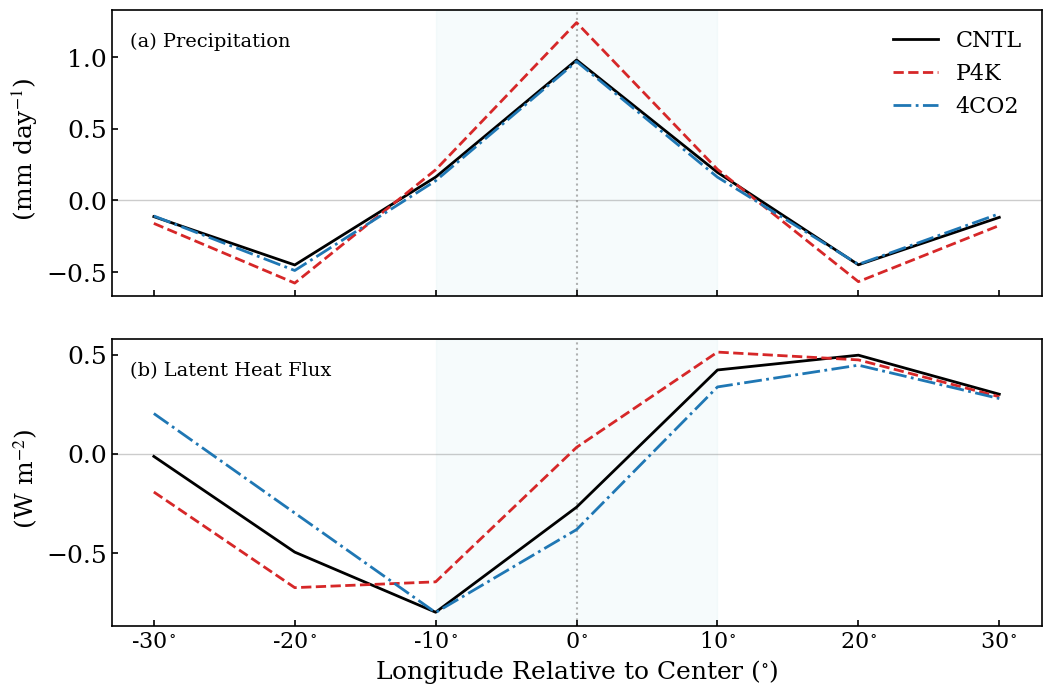


📊 图表已保存（带高亮区域标注）


In [83]:
# ==========================================
# 1. 全局绘图风格设置 (Publication Ready)
# ==========================================
# 使用类似 Seaborn-paper 的风格，但手动调整为学术标准
plt.rcParams.update({
    'font.family': 'serif',             # 衬线字体 (Times New Roman风格)
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif','Arial'],
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'axes.linewidth': 1.2,              # 边框加粗
    'xtick.major.size': 4,
    'xtick.major.width': 1.2,
    'ytick.major.size': 4,
    'ytick.major.width': 1.2,
    'xtick.direction': 'in',            # 刻度朝内 (物理/气象常用)
    'ytick.direction': 'in',
    'mathtext.fontset': 'stix',         # 数学公式字体与Times更贴合
})

# 定义实验的样式字典 (方便统一管理)
style_dict = {
    'CNTL': {'color': 'black',   'linestyle': '-',  'label': 'CNTL', 'lw': 2.0},
    'P4K':  {'color': '#d62728', 'linestyle': '--', 'label': 'P4K',  'lw': 2.0}, # 红色，虚线
    '4CO2': {'color': '#1f77b4', 'linestyle': '-.', 'label': '4CO2', 'lw': 2.0}  # 蓝色，点划线
}

# ==========================================
# 2. 绘图主程序
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True) # sharex对齐上下X轴

# ---------------------------
# 子图 1: 降水 (Precipitation)
# ---------------------------
ax1 = axes[0]

# 先添加填色区域（-10°到10°）
ax1.axvspan(-10, 10, alpha=0.1, color='lightblue', zorder=0,)

for exp in ['CNTL', 'P4K', '4CO2']:
    # 获取数据
    pr_zonal = pr_comp[exp].sel(lat=slice(0,10)).mean(dim='lat')
    
    # 绘图 - 修正：使用 lon_lag 作为 x 坐标
    ax1.plot(pr_zonal.lon_lag, pr_zonal, **style_dict[exp], zorder=2)

# 装饰 Ax1
ax1.set_ylabel(r' (mm day$^{-1}$)') # 使用LaTeX格式单位
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.4, linewidth=1, zorder=1)
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.6, linewidth=1.5, zorder=1)

# 添加子图序号 (a)
ax1.text(0.02, 0.92, '(a) Precipitation', transform=ax1.transAxes, 
         fontsize=14, va='top')

# ---------------------------
# 子图 2: 潜热通量 (LHF)
# ---------------------------
ax2 = axes[1]

# 先添加填色区域（-10°到10°）
ax2.axvspan(-10, 10, alpha=0.1, color='lightblue', zorder=0, )

lhf_dict_data = {
    'CNTL': lhf_composite_cntl,
    'P4K': lhf_composite_p4k,
    '4CO2': lhf_composite_4co2
}

for exp in ['CNTL', 'P4K', '4CO2']: # 保持顺序一致
    lhf_comp = lhf_dict_data[exp]
    # 注意：这里修正了 lat slice 以匹配你的逻辑，请确认你的数据范围
    lhf_zonal = lhf_comp.sel(lat=slice(-15,15)).mean(dim='lat')
    
    # 绘图 - 修正：使用 lon_lag 作为 x 坐标
    ax2.plot(lhf_zonal.lon_lag, lhf_zonal, **style_dict[exp], zorder=2)

# 装饰 Ax2
ax2.set_xlabel(r'Longitude Relative to Center ($^{ \circ }$)') # 更严谨的X轴标签
ax2.set_ylabel(r' (W m$^{-2}$)') # LaTeX单位
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.4, linewidth=1, zorder=1)
ax2.axvline(x=0, color='gray', linestyle=':', alpha=0.6, linewidth=1.5, zorder=1)

# 添加子图序号 (b)
ax2.text(0.02, 0.92, '(b) Latent Heat Flux', transform=ax2.transAxes, 
         fontsize=14,  va='top')

# ==========================================
# 3. 细节调整与图例
# ==========================================

# 为第一个子图创建图例（包含填色区域说明）
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles=handles1, labels=labels1, frameon=False, loc='upper right', ncol=1) 

# 设置刻度格式 (添加度数符号)
xaxis_formatter = ticker.FormatStrFormatter(r'%g$^\circ$')
ax2.xaxis.set_major_formatter(xaxis_formatter)

# 调整布局，防止标签重叠
plt.subplots_adjust(hspace=0.15) # 减小上下图间距

# 保存
plt.savefig(os.path.join(FIG_SAVE_DIR, 'pr_lhf_longitude_evolution_comparison_highlighted.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 图表已保存（带高亮区域标注）")

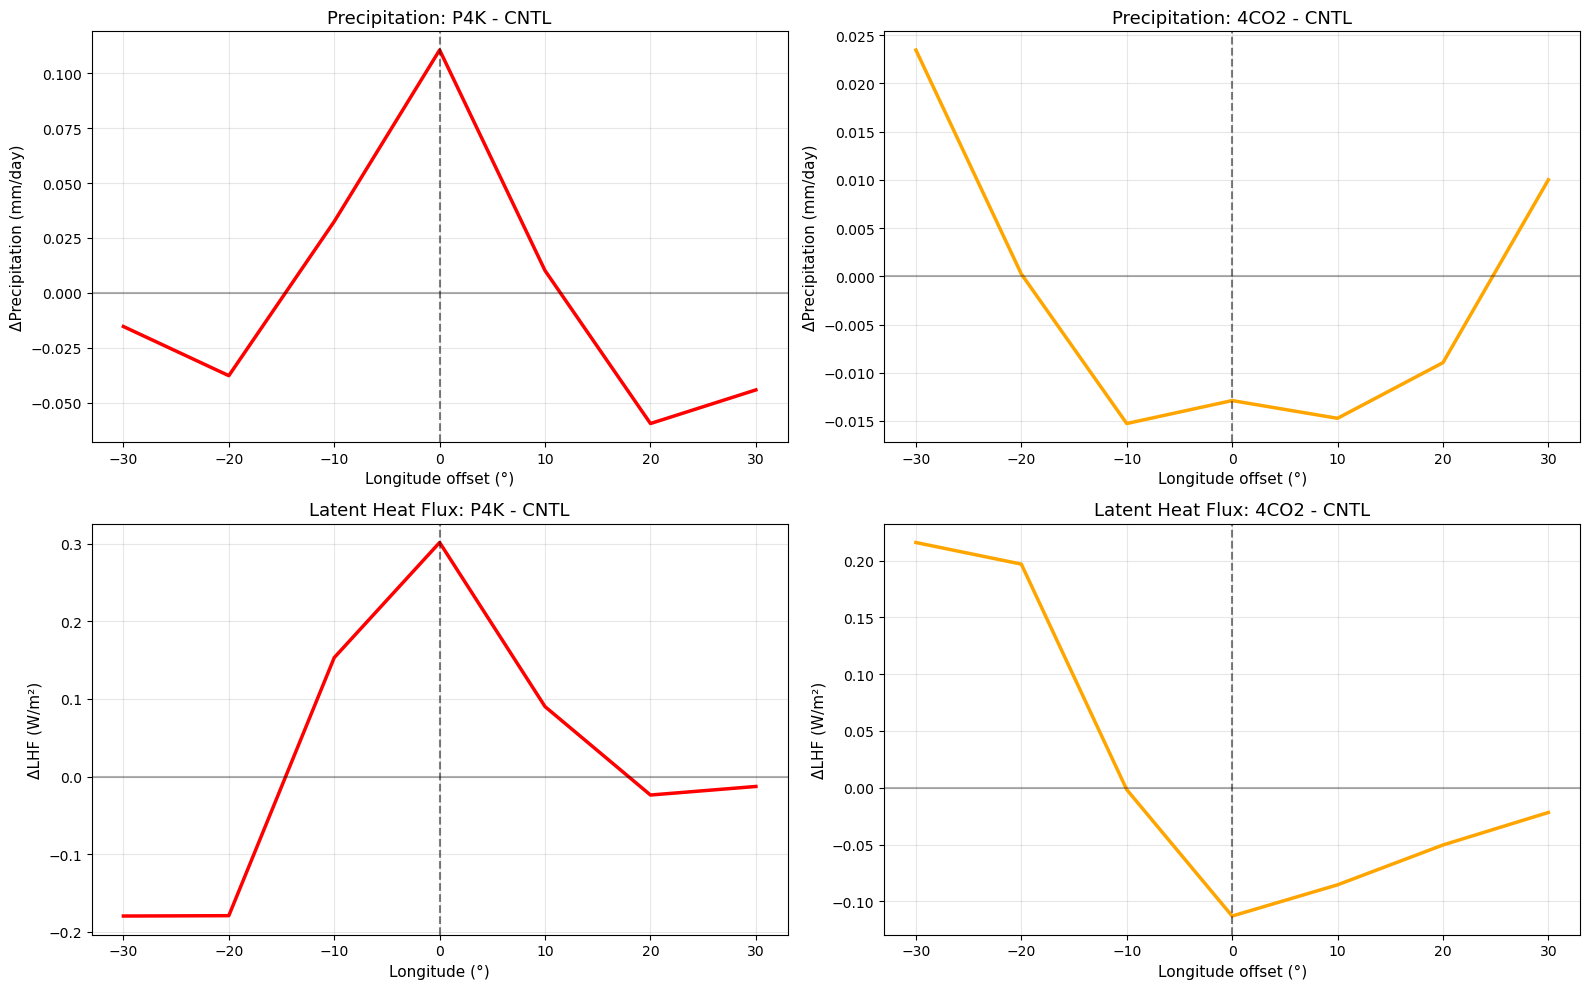


📊 差异图表已保存


In [64]:
# 计算并比较实验间的差异
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. P4K - CNTL 降水差异
ax1 = axes[0, 0]
pr_diff_p4k = (pr_comp['P4K'] - pr_comp['CNTL']).mean(dim='lat')
pr_diff_p4k.plot(ax=ax1, color='red', linewidth=2.5)
ax1.set_xlabel('Longitude offset (°)', fontsize=11)
ax1.set_ylabel('ΔPrecipitation (mm/day)', fontsize=11)
ax1.set_title('Precipitation: P4K - CNTL', fontsize=13, )
ax1.grid(True, alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)

# 2. 4CO2 - CNTL 降水差异
ax2 = axes[0, 1]
pr_diff_4co2 = (pr_comp['4CO2'] - pr_comp['CNTL']).mean(dim='lat')
pr_diff_4co2.plot(ax=ax2, color='orange', linewidth=2.5)
ax2.set_xlabel('Longitude offset (°)', fontsize=11)
ax2.set_ylabel('ΔPrecipitation (mm/day)', fontsize=11)
ax2.set_title('Precipitation: 4CO2 - CNTL', fontsize=13, )
ax2.grid(True, alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)

# 3. P4K - CNTL 潜热通量差异
ax3 = axes[1, 0]
lhf_diff_p4k = (lhf_composite_p4k - lhf_composite_cntl).mean(dim='lat')
lhf_diff_p4k.plot(ax=ax3, color='red', linewidth=2.5)
ax3.set_xlabel('Longitude (°)', fontsize=11)
ax3.set_ylabel('ΔLHF (W/m²)', fontsize=11)
ax3.set_title('Latent Heat Flux: P4K - CNTL', fontsize=13, )
ax3.grid(True, alpha=0.3)
ax3.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax3.axhline(y=0, color='k', linestyle='-', alpha=0.3)

# 4. 4CO2 - CNTL 潜热通量差异
ax4 = axes[1, 1]
lhf_diff_4co2 = (lhf_composite_4co2 - lhf_composite_cntl).mean(dim='lat')
lhf_diff_4co2.plot(ax=ax4, color='orange', linewidth=2.5)
ax4.set_xlabel('Longitude offset (°)', fontsize=11)
ax4.set_ylabel('ΔLHF (W/m²)', fontsize=11)
ax4.set_title('Latent Heat Flux: 4CO2 - CNTL', fontsize=13, )
ax4.grid(True, alpha=0.3)
ax4.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax4.axhline(y=0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
# plt.savefig(os.path.join(FIG_SAVE_DIR, 'pr_lhf_differences_longitude.png'), 
#             dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 差异图表已保存")
